# (17) vH quantize save

**Motivation**: a simulation. host = ```any```, device = ```cuda:3``` <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-vae/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-vae/figs')
tmp_dir = os.path.join(git_dir, 'jb-vae/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.fighelper import *
from vae.train_vae import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from analysis.chosen import *
from figures.analysis import *
from figures.imgs import plot_weights

device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: mach

In [3]:
path = pjoin(os.environ['HOME'], 'Datasets/DOVES')
imgs_file = 'vHimgs.h5'

In [4]:
with h5py.File(pjoin(path, imgs_file), 'r') as f:
    imgs = torch.tensor(f['imgs'][()].T, dtype=torch.float64)

In [12]:
from utils.imgproc import xtract_patches, xtract_patches_random

In [6]:
imgs.min(), imgs.max()

(tensor(0.0608, dtype=torch.float64), tensor(255., dtype=torch.float64))

In [7]:
bins = torch.arange(0, 258) - 0.5

quantized = torch.bucketize(
    input=imgs,
    boundaries=bins,
    right=False,
) - 1

In [8]:
quantized.min(), quantized.max()

(tensor(0), tensor(255))

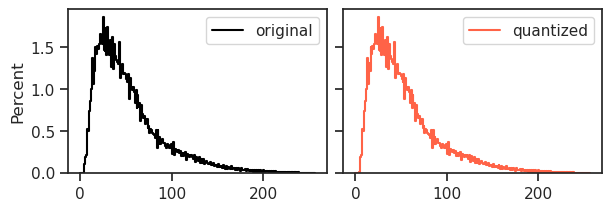

In [9]:
fig, axes = create_figure(1, 2, sharey='row')

histplot(imgs.ravel(), bins=tonp(bins), stat='percent', color='k', label='original', ax=axes[0])
histplot(quantized.ravel(), bins=tonp(bins), stat='percent', color='tomato', label='quantized', ax=axes[1])

add_legend(axes)
plt.show()

In [10]:
imgs.shape, quantized.shape

(torch.Size([101, 768, 1024]), torch.Size([101, 768, 1024]))

In [49]:
npix = 32
patches_quantized = xtract_patches_random(
    dataset=torch.utils.data.dataset.TensorDataset(quantized.unsqueeze(1)),
    npix=npix,
    n_patches=4000,
    batch_size=10,
    verbose=True,
)
patches_quantized.shape

100%|███████████████████████████████████████████| 11/11 [00:05<00:00,  2.04it/s]


torch.Size([404000, 1, 32, 32])

In [50]:
q = 0.5

vars = np.var(tonp(patches_quantized), axis=(-1, -2))
vars = np.log(vars.ravel())
thres = np.quantile(vars, q)
accept = vars > thres

msg = f"# removed: {(~accept).sum()} ——— # final: {accept.sum()}"
print(msg)

# removed: 202000 ——— # final: 202000

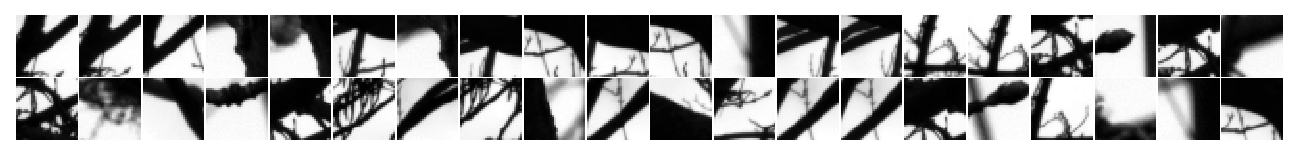

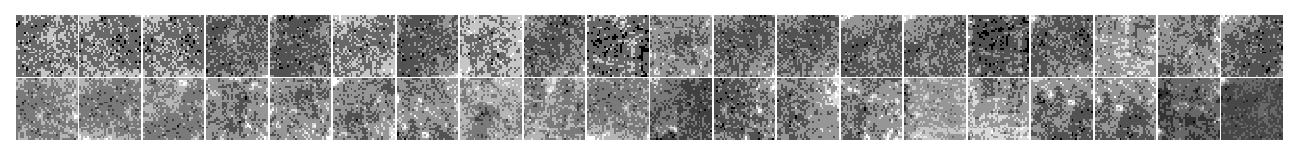

In [51]:
x2p = tonp(patches_quantized)[np.argsort(vars)[::-1]][:40, 0]
_ = plot_weights(x2p, nrows=2)

x2p = tonp(patches_quantized)[np.argsort(vars)][:40, 0]
_ = plot_weights(x2p, nrows=2)

<Axes: ylabel='Count'>

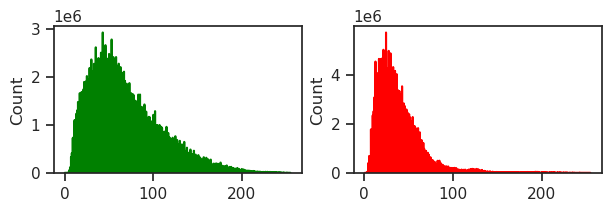

In [53]:
fig, axes = create_figure(1, 2)

histplot(patches_quantized[accept].ravel(), color='g', ax=axes[0])
histplot(patches_quantized[~accept].ravel(), color='r', ax=axes[1])

In [54]:
patches_quantized_accepted = flatten_np(
    patches_quantized, end_dim=1)[accept]

patches_quantized_accepted.shape

torch.Size([202000, 32, 32])

In [55]:
save_dir = pjoin(path, f'vH{npix}')
os.makedirs(save_dir, exist_ok=True)
os.listdir(save_dir)

['patches_quantized.npy']

In [56]:
save_obj(
    obj=tonp(patches_quantized_accepted).astype('float32'),
    file_name='patches_quantized',
    save_dir=save_dir,
    verbose=True,
    mode='npy',
)

[PROGRESS] 'patches_quantized.npy' saved at
/home/hadi/Datasets/DOVES/vH32

In [11]:
imgs

tensor([[[ 98.5227, 100.2399,  98.5227,  ..., 108.8258, 105.1768, 107.1086],
         [101.8497, 101.8497, 100.2399,  ..., 108.8258, 105.1768, 108.8258],
         [100.2399,  98.5227,  98.5227,  ..., 107.1086, 107.1086, 108.8258],
         ...,
         [ 13.2008,  12.2348,  12.2348,  ..., 222.3737, 222.3737, 188.4596],
         [ 13.2008,  13.2008,  14.1667,  ..., 222.3737, 224.7348, 188.4596],
         [ 14.1667,  15.0253,  14.1667,  ..., 222.3737, 213.0366, 190.8207]],

        [[ 48.4664,  54.2619,  62.0062,  ...,  28.0541,  25.4385,  26.8232],
         [ 30.1056,  37.7474,  47.6458,  ...,  19.9507,  18.2582,  20.5149],
         [ 38.5680,  50.9795,  52.5694,  ...,  16.0016,  14.3604,  17.6941],
         ...,
         [ 40.7220,  22.3612,  26.8232,  ...,  14.3604,  19.3866,  14.3604],
         [ 27.3874,  24.2076,  40.7220,  ...,  11.7448,  15.3862,  13.7963],
         [ 23.5921,  34.8753,  72.9817,  ...,   7.8982,   9.2317,   9.8471]],

        [[ 60.7595,  49.3671,  39.5570,  ...

In [12]:
quantized

tensor([[[ 99, 100,  99,  ..., 109, 105, 107],
         [102, 102, 100,  ..., 109, 105, 109],
         [100,  99,  99,  ..., 107, 107, 109],
         ...,
         [ 13,  12,  12,  ..., 222, 222, 188],
         [ 13,  13,  14,  ..., 222, 225, 188],
         [ 14,  15,  14,  ..., 222, 213, 191]],

        [[ 48,  54,  62,  ...,  28,  25,  27],
         [ 30,  38,  48,  ...,  20,  18,  21],
         [ 39,  51,  53,  ...,  16,  14,  18],
         ...,
         [ 41,  22,  27,  ...,  14,  19,  14],
         [ 27,  24,  41,  ...,  12,  15,  14],
         [ 24,  35,  73,  ...,   8,   9,  10]],

        [[ 61,  49,  40,  ...,  61,  69,  65],
         [ 68,  56,  48,  ...,  56,  61,  61],
         [ 87,  70,  65,  ...,  54,  58,  56],
         ...,
         [ 22,  23,  21,  ...,  23,  24,  23],
         [ 23,  23,  20,  ...,  19,  20,  18],
         [ 19,  22,  20,  ...,  17,  17,  19]],

        ...,

        [[ 10,   9,   8,  ...,  36,  25,  22],
         [ 10,   8,   9,  ...,  23,  23,  28]